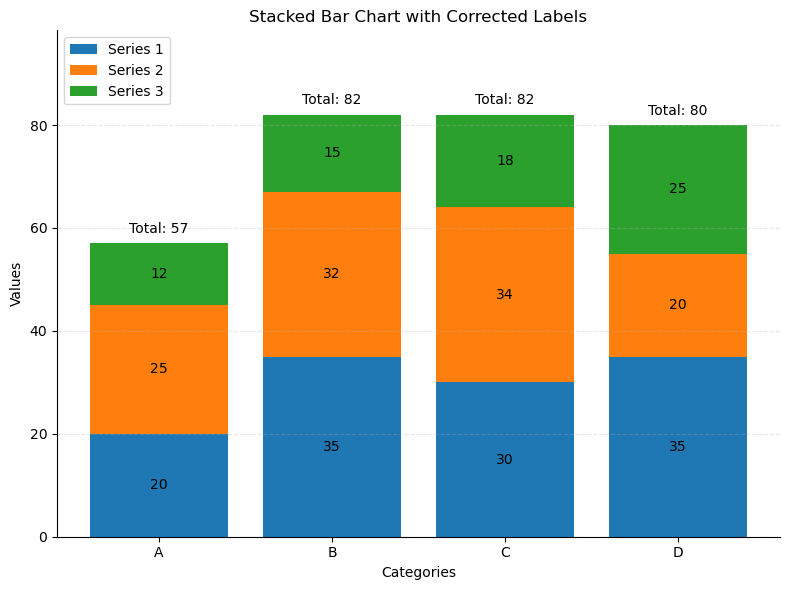

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 示例数据
categories = ['A', 'B', 'C', 'D']
series1 = [20, 35, 30, 35]
series2 = [25, 32, 34, 20]
series3 = [12, 15, 18, 25]

# 创建图形
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制堆叠柱状图
bars1 = ax.bar(categories, series1, label='Series 1')
bars2 = ax.bar(categories, series2, bottom=series1, label='Series 2')
bars3 = ax.bar(categories, series3, bottom=np.array(series1)+np.array(series2), label='Series 3')

# 修正后的添加数据标签函数
def add_labels(bars, bottoms=None):
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if bottoms is None:
            y = bar.get_y() + height/2
        else:
            y = bottoms[i] + height/2
        ax.text(bar.get_x() + bar.get_width()/2., y,
                f'{height}', ha='center', va='center')

# 添加标签
add_labels(bars1)
add_labels(bars2, bottoms=series1)
add_labels(bars3, bottoms=np.array(series1)+np.array(series2))

# 添加总数值标签
totals = np.array(series1) + np.array(series2) + np.array(series3)
for i, total in enumerate(totals):
    ax.text(i, total + 2, f'Total: {total}', ha='center')

# 美化样式
ax.set_ylim(0, max(totals)*1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_xlabel('Categories')
ax.set_ylabel('Values')
ax.set_title('Stacked Bar Chart with Corrected Labels')
ax.legend()

plt.tight_layout()
plt.savefig('堆叠柱状图-带数据标签.png', dpi=400, bbox_inches='tight')
plt.show()